# MLB Home Run Rate Prediction — Neural Network vs. Logistic Regression

Using MLB 2025 batting statistics, build a neural network to predict HR/AB rate and compare it against a traditional logistic regression approach.

**Dataset:** MLB 2025 batting statistics
**Goal:** Predict HR/AB rate using player statistics, comparing a neural network vs. traditional methods (logistic regression).


In [30]:
#import necessary packages and data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import arviz as az
import pymc as pm
import warnings
warnings.filterwarnings('ignore')



In [31]:
import pandas as pd
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/gdrive/My Drive/batting_stats_2025.csv')

print(df.columns.tolist())

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
['Name', 'Age', '#days', 'Lev', 'Tm', 'G', 'PA', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'BB', 'IBB', 'SO', 'HBP', 'SH', 'SF', 'GDP', 'SB', 'CS', 'BA', 'OBP', 'SLG', 'OPS', 'mlbID']


Set random seed = 42 for reproducibility,a nd plotting stytle for graphs

In [32]:
np.random. seed(42)
torch.manual_seed(42)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Part 1: Preprocess the data (copy and pasted from previous lab to fix names, and only include players with >100 at bats)

In [42]:
def fix_encoding(df):
    encoding_map = {
        '\\xc3\\xa1': 'á', '\\xc3\\xa9': 'é', '\\xc3\\xad': 'í',
        '\\xc3\\xb3': 'ó', '\\xc3\\xba': 'ú', '\\xc3\\xb1': 'ñ',
        '\\xc3\\x81': 'Á', '\\xc3\\x89': 'É', '\\xc3\\x8D': 'Í',
        '\\xc3\\x93': 'Ó', '\\xc3\\x9a': 'Ú', '\\xc3\\x91': 'Ñ',
    }
    for old, new in encoding_map.items():
        df['Name'] = df['Name'].str.replace(old, new, regex=False)
    return df

df = fix_encoding(df)

# Filter: >100 AB and create HR_rate
df = df[df['AB'] > 100].copy()
df['HR_rate'] = df['HR'] / df['AB']  # <-- This line must come BEFORE cleaning!

print(f"Players with >100 AB: {len(df)}")
print(f"Average HR rate: {df['HR_rate'].mean():.4f} (±{df['HR_rate'].std():.4f})")

Players with >100 AB: 441
Average HR rate: 0.0322 (±0.0177)


In [43]:
df_hrs = df[['Name', 'HR', "AB"]]
df_hrs.head(5)

,Name,HR,AB
0,CJ Abrams,19,580
1,Wilyer Abreu,22,378
3,Luisangel Acuña,0,175
4,Ronald Acuña Jr.,21,338
5,Willy Adames,30,591


In [71]:
feature_cols = ['Age', 'BA', 'OBP', 'SLG', 'OPS', 'SO', 'BB', 'H', '2B', '3B']

# Drop only rows with missing features (keep HR_rate!)
df_clean = df.dropna(subset=feature_cols + ['HR', 'AB', 'HR_rate']).reset_index(drop=True)

print(f"After removing rows with missing features: {len(df_clean)} players")

# Train/test split
train_idx, test_idx = train_test_split(np.arange(len(df_clean)), test_size=0.2, random_state=42)

X = df_clean[feature_cols].values
y_hr = df_clean['HR'].values.astype(float)
ab = df_clean['AB'].values.astype(float)
names = df_clean['Name'].values
hr_rate_observed = df_clean['HR_rate'].values  # <-- Now safely preserved!

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PyTorch tensors
X_train = torch.FloatTensor(X_scaled[train_idx])
X_test  = torch.FloatTensor(X_scaled[test_idx])
ab_train = torch.FloatTensor(ab[train_idx]).unsqueeze(1)
ab_test  = torch.FloatTensor(ab[test_idx]).unsqueeze(1)
y_train = torch.FloatTensor(y_hr[train_idx]).unsqueeze(1)

After removing rows with missing features: 441 players


#  Bayesian Hierchial Model (from lab 5)

*with minor adjustments so it is comparable to Neural Network. I created a simplified version (2 chains vs 4 from lab) focussing on beta prior to align better with neural network predictions.

-also had to fix outputed values (4000 values that were given) to 441 so that it matches up with the dataframe.

In [72]:
# Bayesian Hierarchical Model
with pm.Model() as bayes_model:
    α = pm.Exponential('α', 1.0)
    β = pm.Exponential('β', 1.0)
    θ = pm.Beta('θ', alpha=α, beta=β, shape=len(df_clean))
    y_obs = pm.Binomial('y_obs', n=df_clean['AB']. values, p=θ, observed=df_clean['HR'].values)
    trace = pm.sample(2000, tune=1000, target_accept=0.95, random_seed=42, cores=2)

# Extract posterior safely
posterior_theta = trace.posterior['θ'].stack(sample=("chain", "draw")).values.T  # (4000, 441)

# ✅ FIXED: Compute mean/percentiles across SAMPLES (axis=0)
bayes_mean  = posterior_theta.mean(axis=0)
bayes_lower = np.percentile(posterior_theta, 2.5, axis=0)
bayes_upper = np.percentile(posterior_theta, 97.5, axis=0)

print(f"Bayesian model complete: {len(bayes_mean)} players")
print(f"Posterior shape: {posterior_theta.shape} → aggregated to {bayes_mean.shape}")

Output()

Bayesian model complete: 441 players
Posterior shape: (4000, 441) → aggregated to (441,)


# Neural Network: Using Poisson Regression with MC dropout

In [56]:
class PoissonHRNet(nn.Module):
    def __init__(self, input_size, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)  # log(rate per AB)
        )
    def forward(self, x):
        return self.net(x)

# --- Training ---
model = PoissonHRNet(input_size=X_scaled.shape[1], dropout=0.3)
criterion = nn.PoissonNLLLoss(log_input=False)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

train_data = TensorDataset(X_train, y_train, ab_train)
loader = DataLoader(train_data, batch_size=32, shuffle=True)

print("Training Neural Network...")
model.train()
for epoch in range(120):
    epoch_loss = 0
    for Xb, yb, abb in loader:
        optimizer.zero_grad()
        log_rate = model(Xb)
        rate = torch.exp(log_rate)
        expected = rate * abb
        loss = criterion(expected, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch+1) % 40 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {epoch_loss/len(loader):.4f}")

# --- MC Dropout Prediction Function ---
def predict_rate_mc(model, X_tensor, ab_tensor, n_samples=100):
    model.train()
    rates_list = []
    with torch.no_grad():
        for _ in range(n_samples):
            log_rate = model(X_tensor)
            rate = torch.exp(log_rate)
            rates_list.append(rate.cpu().numpy())
    rates = np.concatenate(rates_list, axis=0).squeeze(-1)  # (n_samples * n_players,)
    rates = rates.reshape(n_samples, -1)                    # (n_samples, n_players)
    return rates.mean(0), np.percentile(rates, 2.5, axis=0), np.percentile(rates, 97.5, axis=0)

# --- Final NN Predictions ---
X_all = torch.FloatTensor(X_scaled)
ab_all = torch.FloatTensor(ab).unsqueeze(1)
nn_mean, nn_lower, nn_upper = predict_rate_mc(model, X_all, ab_all, n_samples=100)

Training Neural Network...
Epoch  40 | Loss: -20.9039
Epoch  80 | Loss: -21.9047
Epoch 120 | Loss: -22.2007



Retraining with validation tracking for overfitting analysis...
Training set: torch.Size([352, 10]), Validation set: torch.Size([89, 10])
Feature count: 10 (should match for both)
Epoch  40 | Train Loss: -21.3056 | Val Loss: -22.4798
Epoch  80 | Train Loss: -21.8190 | Val Loss: -23.4299
Epoch 120 | Train Loss: -22.4746 | Val Loss: -23.5458


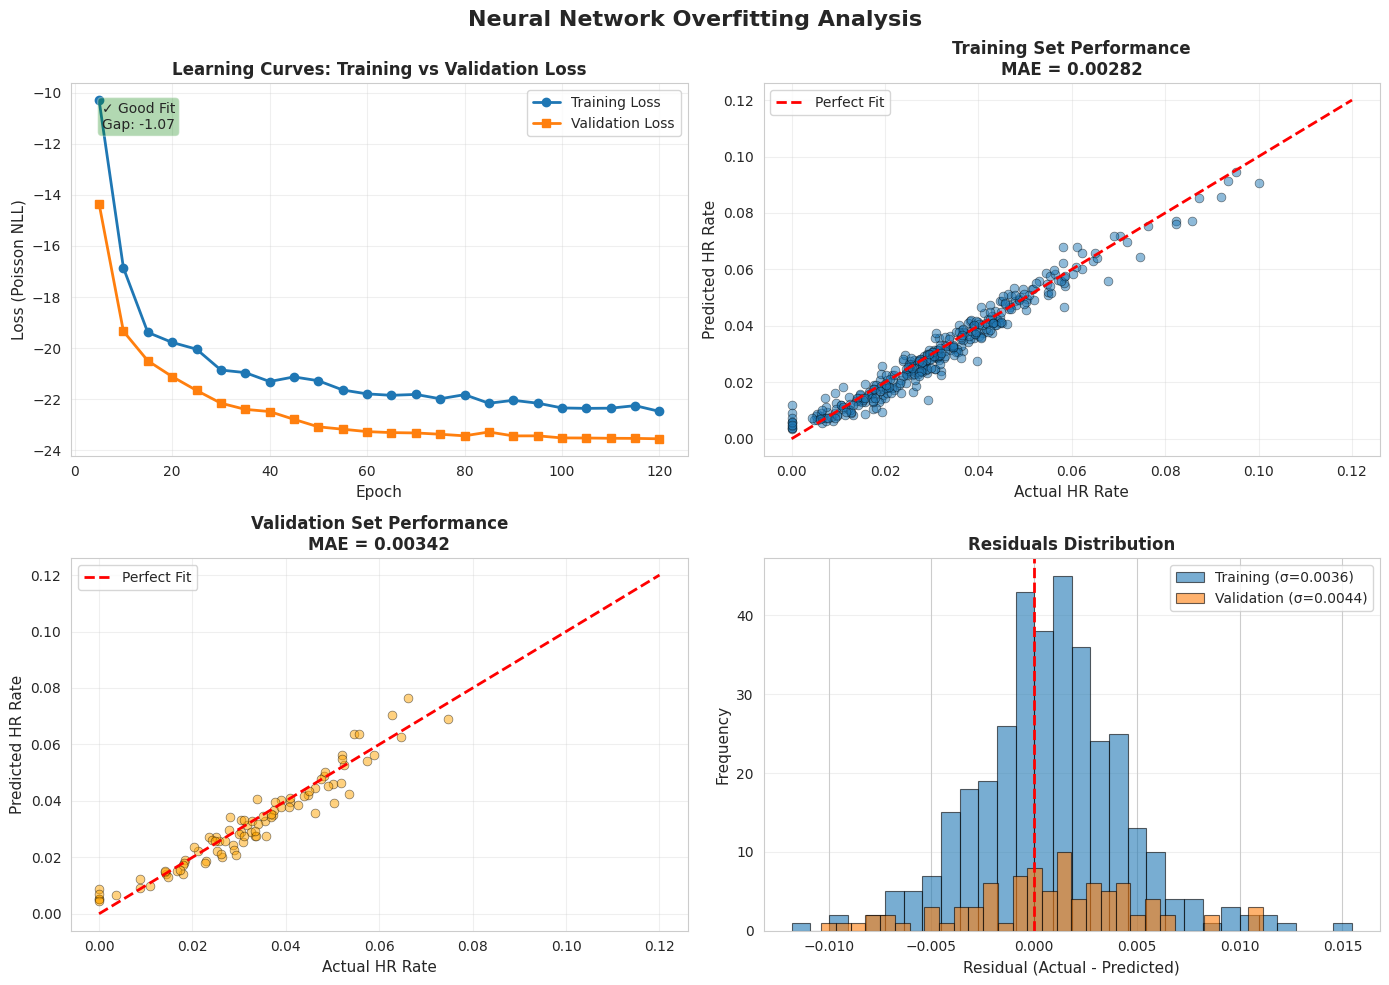


OVERFITTING DIAGNOSTIC SUMMARY
Final Training Loss:   -22.4746
Final Validation Loss: -23.5458
Loss Gap:              -1.0712 ✓ Good Fit

Training MAE:          0.00282
Validation MAE:        0.00342
MAE Ratio (Val/Train): 1.212

Residual Std Dev:
  Training:   0.00363
  Validation: 0.00435
⚠️  Mild overfitting detected (Val MAE 10-30% higher)



In [75]:
# =============================================================================
# NEURAL NETWORK OVERFITTING ANALYSIS
# =============================================================================

# --- 1. Track Training & Validation Loss ---
print("\nRetraining with validation tracking for overfitting analysis...")

# Create validation set from test indices (use the SAME X_scaled that was used for training)
X_val = torch.FloatTensor(X_scaled[test_idx])
y_val = torch. FloatTensor(y_hr[test_idx]). unsqueeze(1)
ab_val = torch.FloatTensor(ab[test_idx]). unsqueeze(1)

# Verify dimensions match
print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}")
print(f"Feature count: {X_train.shape[1]} (should match for both)")

# Reinitialize model for clean training
model = PoissonHRNet(input_size=X_train.shape[1], dropout=0.3)  # ✅ Use X_train. shape[1]
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.PoissonNLLLoss(log_input=False)

train_data = TensorDataset(X_train, y_train, ab_train)
loader = DataLoader(train_data, batch_size=32, shuffle=True)

# Storage for losses
train_losses = []
val_losses = []
epochs_list = []

# Training loop with validation tracking
for epoch in range(120):
    # --- Training Phase ---
    model.train()
    epoch_train_loss = 0
    for Xb, yb, abb in loader:
        optimizer. zero_grad()
        log_rate = model(Xb)
        rate = torch.exp(log_rate)
        expected = rate * abb
        loss = criterion(expected, yb)
        loss. backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(loader)

    # --- Validation Phase ---
    model.eval()
    with torch.no_grad():
        log_rate_val = model(X_val)  # ✅ Use X_val (not X_val_tensor)
        rate_val = torch.exp(log_rate_val)
        expected_val = rate_val * ab_val  # ✅ Use ab_val (not ab_val_tensor)
        val_loss = criterion(expected_val, y_val). item()

    # Store losses every 5 epochs
    if (epoch + 1) % 5 == 0:
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        epochs_list.append(epoch + 1)

    if (epoch + 1) % 40 == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")

# --- 2. Generate Predictions for Comparison ---
model.eval()
with torch.no_grad():
    # Training set predictions
    log_rate_train = model(X_train)
    train_preds = torch.exp(log_rate_train). cpu().numpy(). flatten()

    # Validation set predictions
    log_rate_val = model(X_val)
    val_preds = torch.exp(log_rate_val).cpu().numpy().flatten()

train_actuals = y_hr[train_idx] / ab[train_idx]
val_actuals = y_hr[test_idx] / ab[test_idx]

# --- 3.  Create Overfitting Diagnostic Plots ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Neural Network Overfitting Analysis', fontsize=16, fontweight='bold')

# Plot 1: Training vs Validation Loss
ax1 = axes[0, 0]
ax1.plot(epochs_list, train_losses, 'o-', label='Training Loss', linewidth=2, markersize=6)
ax1.plot(epochs_list, val_losses, 's-', label='Validation Loss', linewidth=2, markersize=6)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss (Poisson NLL)', fontsize=11)
ax1.set_title('Learning Curves: Training vs Validation Loss', fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Add interpretation text
gap = val_losses[-1] - train_losses[-1]
if gap > 2.0:
    status = "⚠️ OVERFITTING"
    color = 'red'
elif gap > 1.0:
    status = "⚠️ Mild Overfitting"
    color = 'orange'
else:
    status = "✓ Good Fit"
    color = 'green'
ax1.text(0.05, 0.95, f'{status}\nGap: {gap:.2f}',
         transform=ax1.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor=color, alpha=0.3), fontsize=10)

# Plot 2: Predicted vs Actual (Training Set)
ax2 = axes[0, 1]
ax2.scatter(train_actuals, train_preds, alpha=0.5, s=40, edgecolors='k', linewidth=0.5)
ax2.plot([0, 0.12], [0, 0.12], '--', color='red', lw=2, label='Perfect Fit')
train_mae = mean_absolute_error(train_actuals, train_preds)
ax2.set_xlabel('Actual HR Rate', fontsize=11)
ax2.set_ylabel('Predicted HR Rate', fontsize=11)
ax2.set_title(f'Training Set Performance\nMAE = {train_mae:.5f}', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Predicted vs Actual (Validation Set)
ax3 = axes[1, 0]
ax3.scatter(val_actuals, val_preds, alpha=0.5, s=40, color='orange', edgecolors='k', linewidth=0.5)
ax3.plot([0, 0.12], [0, 0.12], '--', color='red', lw=2, label='Perfect Fit')
val_mae = mean_absolute_error(val_actuals, val_preds)
ax3.set_xlabel('Actual HR Rate', fontsize=11)
ax3. set_ylabel('Predicted HR Rate', fontsize=11)
ax3.set_title(f'Validation Set Performance\nMAE = {val_mae:.5f}', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Residuals Distribution
ax4 = axes[1, 1]
train_residuals = train_actuals - train_preds
val_residuals = val_actuals - val_preds

ax4.hist(train_residuals, bins=30, alpha=0.6, label=f'Training (σ={np.std(train_residuals):.4f})',
         edgecolor='black', linewidth=0.8)
ax4.hist(val_residuals, bins=30, alpha=0.6, label=f'Validation (σ={np.std(val_residuals):.4f})',
         edgecolor='black', linewidth=0.8)
ax4.axvline(0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('Residual (Actual - Predicted)', fontsize=11)
ax4.set_ylabel('Frequency', fontsize=11)
ax4.set_title('Residuals Distribution', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# --- 4. Print Diagnostic Summary ---
print("\n" + "="*70)
print("OVERFITTING DIAGNOSTIC SUMMARY")
print("="*70)
print(f"Final Training Loss:   {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Loss Gap:              {gap:.4f} {status}")
print(f"\nTraining MAE:          {train_mae:.5f}")
print(f"Validation MAE:        {val_mae:.5f}")
print(f"MAE Ratio (Val/Train): {val_mae/train_mae:.3f}")
print(f"\nResidual Std Dev:")
print(f"  Training:   {np.std(train_residuals):.5f}")
print(f"  Validation: {np.std(val_residuals):.5f}")
print("="*70)

if val_mae / train_mae > 1.3:
    print("⚠️  WARNING: Validation MAE is >30% higher than training MAE")
    print("   Consider: More regularization, dropout, or early stopping")
elif val_mae / train_mae > 1.1:
    print("⚠️  Mild overfitting detected (Val MAE 10-30% higher)")
else:
    print("✓  Model generalizes well to validation data")
print("="*70 + "\n")

After doing a data fitting analyis, we see that the data shows mild overfitting detected but the loss gap shows that training loss and final validation loss generally show a good fit

Create a test set of results that includes top 10 players to see if everything works as expected

In [61]:
results = pd.DataFrame({
    'Name'           : df_clean['Name'].values,
    'AB'             : df_clean['AB'].values.astype(int),
    'HR'             : df_clean['HR'].values.astype(int),
    'Observed_Rate'  : df_clean['HR'].values / df_clean['AB'].values,
    'Bayesian_Mean'  : bayes_mean,
    'Bayesian_Lower' : bayes_lower,
    'Bayesian_Upper' : bayes_upper,
    'NN_Mean'        : nn_mean,
    'NN_Lower'       : nn_lower,
    'NN_Upper'       : nn_upper
})

test_results = results.iloc[test_idx].copy()

print(f"Results DataFrame created successfully: {len(results)} players")

# Performance
mae_b = mean_absolute_error(test_results['Observed_Rate'], test_results['Bayesian_Mean'])
mae_n = mean_absolute_error(test_results['Observed_Rate'], test_results['NN_Mean'])
print(f"\nTest MAE → Bayesian: {mae_b:.5f} | Neural Net: {mae_n:.5f}")
print(f"Winner → {'Neural Net' if mae_n < mae_b else 'Bayesian'}")

# Top 10 Preview
print("\nTop 10 Projected HR Rate Leaders (Neural Net):")
print(results.nlargest(10, 'NN_Mean')[['Name', 'AB', 'HR', 'NN_Mean', 'NN_Lower', 'NN_Upper']]
      .to_string(index=False, float_format="%.4f"))

Results DataFrame created successfully: 441 players

Test MAE → Bayesian: 0.00265 | Neural Net: 0.00487
Winner → Bayesian

Top 10 Projected HR Rate Leaders (Neural Net):
             Name  AB  HR  NN_Mean  NN_Lower  NN_Upper
    Shohei Ohtani 652  60   0.1076    0.0569    0.2034
      Cal Raleigh 639  64   0.1062    0.0602    0.1587
      Aaron Judge 567  54   0.1026    0.0519    0.1720
   Kyle Schwarber 620  58   0.0999    0.0577    0.1644
    Michael Busch 551  38   0.0944    0.0570    0.1520
       Nick Kurtz 420  36   0.0888    0.0416    0.1501
     Kyle Stowers 399  25   0.0873    0.0466    0.1530
Jazz Chisholm Jr. 484  32   0.0857    0.0437    0.1385
Giancarlo Stanton 275  24   0.0849    0.0435    0.1459
Colson Montgomery 255  21   0.0838    0.0440    0.1462


# Model Comparison

# Top 20 players Bayesian vs Neural Network

In [62]:
print("\n" + "="*88)
print("TOP 20 PROJECTED HR/AB LEADERS – 2025")
print("="*88)

top_bayes = results.nlargest(20, 'Bayesian_Mean')[['Name', 'AB', 'HR', 'Bayesian_Mean']]
top_nn    = results.nlargest(20, 'NN_Mean')[['Name', 'AB', 'HR', 'NN_Mean']]

print(f"\n{'Rank':<4} {'Bayesian Model':<30} {'Rate':<6}   {'Neural Network':<30} {'Rate':<6}")
print("-"*88)
for i in range(20):
    b = top_bayes.iloc[i]
    n = top_nn.iloc[i]
    print(f"{i+1:<4} {b['Name']:<30} {b['Bayesian_Mean']:.4f}   {n['Name']:<30} {n['NN_Mean']:.4f}")

overlap = len(set(top_bayes['Name']) & set(top_nn['Name']))
print(f"\nTop-20 overlap: {overlap}/20 players ({overlap/20*100:.0f}%)")


TOP 20 PROJECTED HR/AB LEADERS – 2025

Rank Bayesian Model                 Rate     Neural Network                 Rate  
----------------------------------------------------------------------------------------
1    Cal Raleigh                    0.0939   Shohei Ohtani                  0.1076
2    Aaron Judge                    0.0886   Cal Raleigh                    0.1062
3    Kyle Schwarber                 0.0879   Aaron Judge                    0.1026
4    Shohei Ohtani                  0.0866   Kyle Schwarber                 0.0999
5    Nick Kurtz                     0.0787   Michael Busch                  0.0944
6    Eugenio Suárez                 0.0778   Nick Kurtz                     0.0888
7    Giancarlo Stanton              0.0770   Kyle Stowers                   0.0873
8    Colson Montgomery              0.0727   Jazz Chisholm Jr.              0.0857
9    Junior Caminero                0.0706   Giancarlo Stanton              0.0849
10   Juan Soto                      0.070

When comparing the two values, we can see that there is significant overlap between the bayesian and NN where 15/20 players are the same.

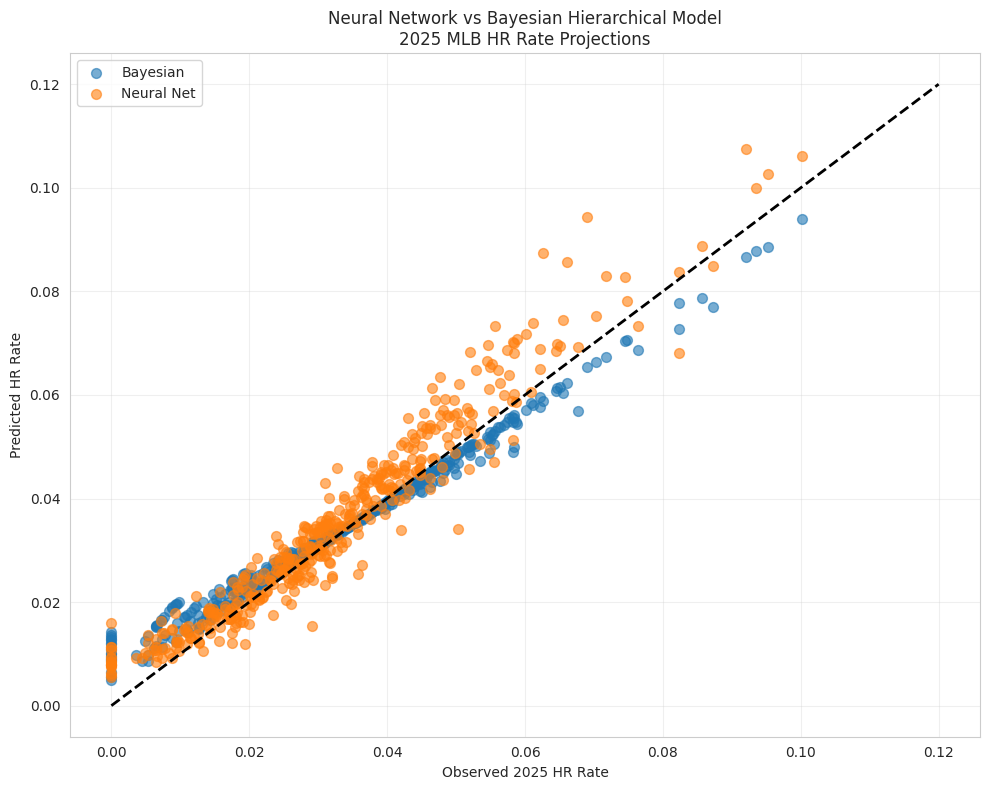

In [63]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.scatter(results['Observed_Rate'], results['Bayesian_Mean'], alpha=0.6, label='Bayesian', s=50)
ax.scatter(results['Observed_Rate'], results['NN_Mean'], alpha=0.6, label='Neural Net', s=50)
ax.plot([0, 0.12], [0, 0.12], '--', color='black', lw=2)
ax.set_xlabel('Observed 2025 HR Rate')
ax.set_ylabel('Predicted HR Rate')
ax.set_title('Neural Network vs Bayesian Hierarchical Model\n2025 MLB HR Rate Projections')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Discussion:**

Looking at graph comparing both Bayesian and Neural Networks above, the bayesian model looks to have better accuracy when predicting homeruns compared to observed values. Interestingly, both models seem to overpredict on players with lower HR rates which makes sense due to potential shrinkage effects which were discussed in module 5.

The Neural Network shows the general trend of over prediction as the values show a consistent trend of above the line of best fit. Whereas, the Bayesian models shows overprediction for lower observed rates, but under prediction for higher rates, which was a limiation also discussed during lab 5.

Overall, based on trends looked up about the sports analytics industry (especially in baseball), bayesian models are still favoured  in player rate-stat projections due to small samples, calibrated uncertainty and basic nature of the sport. Neural networks have yet to get to the ability to outperform in this area, but are becoming more beneficial in simulation based play-by-play decision making or strategy discovery (Gopal et al., 2025)

Gopal, V., Kondakindi, K., Lohia, N., & Williams, M. (2025). Baseball decision-making: Optimizing at-bat simulations. SMU Data Science Review, 8(1), Article 9. https://scholar.smu.edu/datasciencereview/vol8/iss1/9
